# Linear-System Classical Baselines vs QSVT Resource Proxies

This notebook treats a finite-difference Poisson system as a package-client benchmark. It compares dense linear solve (DLS) and conjugate gradient solve (CGS) baselines against a QSVT inverse-polynomial resource proxy.

## Benchmark Scope, QSVT Proxy Strategy, and Interpretation

**Benchmark scope.** This notebook times dense linear solve (DLS) and conjugate gradient solve (CGS) baselines on a small finite-difference Poisson system. The timings are classical Python/NumPy measurements for the supplied finite matrix.

**QSVT proxy strategy.** The QSVT fields use a bounded positive-inverse polynomial for the scaled spectrum. They report degree, coefficient count, and signal-operator call proxies; they do not time a quantum circuit.

**Interpretation.** The benchmark separates classical residual/timing diagnostics from QSVT resource metadata. Quantum advantage would require separate assumptions about scalable block encoding, state preparation, precision, success probability, and readout.


## Variable definitions

- `n`: Poisson matrix dimension.
- `grid`, `operator`: Dirichlet grid and positive finite-difference Laplacian.
- `rhs`: right-hand side vector for the linear system.
- `eigenvalues`: exact spectrum used to compute conditioning and scaling metadata.
- `gamma`: scaled minimum eigenvalue for the inverse-polynomial design.
- `inverse_coeffs`: positive-inverse polynomial coefficients.
- `dense_report`, `cg_report`: DLS and CGS benchmark reports.
- `reports`, `rows`: report collection and rendered summary rows.
- `ARTIFACT_DIR`, `TABLE_DIR`: output directories for JSON and CSV benchmark artifacts.
- `fig`, `axes`, and similar names are plotting helpers.


## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from qsvt import (
    conjugate_gradient_benchmark,
    dense_linear_solve_benchmark,
    design_positive_inverse_polynomial,
    dirichlet_laplacian_1d,
    plot_benchmark_timings,
    plot_qsvt_proxy_resources,
    save_report,
    write_benchmark_summary_csv,
)


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("could not locate repository root")


ROOT = find_repo_root()
ARTIFACT_DIR = ROOT / "results/benchmarks"
TABLE_DIR = ROOT / "results/tables"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def fmt(value):
    if value is None:
        return "n/a"
    if isinstance(value, (list, tuple, set)):
        return ", ".join(fmt(item) for item in value)
    if isinstance(value, float):
        if value == 0.0:
            return "0"
        if abs(value) < 1e-3 or abs(value) >= 1e4:
            return f"{value:.2e}"
        return f"{value:.4g}"
    return str(value)


def display_table(title, rows, columns):
    rendered = [
        [str(header), *[fmt(accessor(row)) for row in rows]]
        for header, accessor in columns
    ]
    widths = [max(len(item) for item in row) for row in rendered]

    print(title)
    print("-" * len(title))
    for row, width in zip(rendered, widths):
        print(f"{row[0]:<{width}} : " + " | ".join(row[1:]))

## Poisson System

In [2]:
n = 12
grid, operator = dirichlet_laplacian_1d(n)
rhs = np.sin(np.pi * grid)

eigenvalues = np.linalg.eigvalsh(operator)
gamma = float(np.min(eigenvalues) / np.max(eigenvalues))
inverse_coeffs = design_positive_inverse_polynomial(gamma=gamma, degree=9)

problem_summary = {
    "dimension": n,
    "condition_number": float(np.linalg.cond(operator)),
    "gamma": gamma,
    "inverse_degree": len(inverse_coeffs) - 1,
}
display_table(
    "Poisson system",
    [problem_summary],
    [
        ("Dimension", lambda row: row["dimension"]),
        ("Condition number", lambda row: row["condition_number"]),
        ("Scaled spectral gap gamma", lambda row: row["gamma"]),
        ("Inverse polynomial degree", lambda row: row["inverse_degree"]),
    ],
)

Poisson system
--------------
Dimension : 12
Condition number : 67.83
Scaled spectral gap gamma : 0.01474
Inverse polynomial degree : 9


## Baseline Reports

## Quantum-Advantage Interpretation

For this small dense notebook problem, DLS and CGS are the right classical references and no quantum advantage is claimed. A QSVT linear-system solver can become interesting only in a larger sparse or block-encoded regime where state preparation is efficient, the condition number is controlled, and the desired output is a state or expectation value rather than a full classical solution vector. The proxy below isolates the inverse-polynomial degree and signal-call count so users can see which part of a possible quantum workflow would need to beat the classical baseline.

## Visual diagnostics

The plots separate classical timing and residuals from QSVT signal-call proxy metadata.

Benchmark readout
-----------------
Dense relative residual : 2.78e-15
CGS relative residual : 7.68e-15
CGS iterations : 1
QSVT signal calls : 9


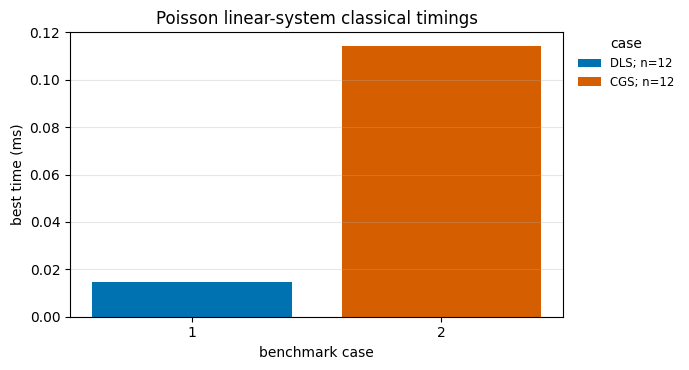

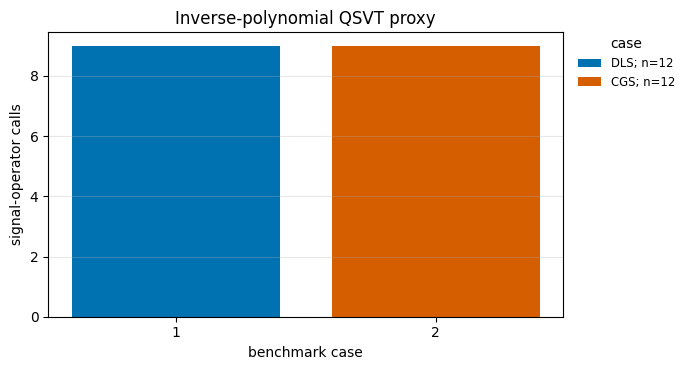

In [3]:
dense_report = dense_linear_solve_benchmark(
    operator,
    rhs,
    repeats=3,
    qsvt_coeffs=inverse_coeffs,
)
cg_report = conjugate_gradient_benchmark(
    operator,
    rhs,
    tolerance=1e-10,
    repeats=3,
    qsvt_coeffs=inverse_coeffs,
)

save_report(dense_report, ARTIFACT_DIR / "linear_system_dense_solve.json")
save_report(cg_report, ARTIFACT_DIR / "linear_system_cg_solve.json")
write_benchmark_summary_csv(
    [dense_report, cg_report],
    TABLE_DIR / "linear_system_benchmark_summary.csv",
)

summary = {
    "dense_relative_residual": dense_report["metrics"]["relative_residual_norm"],
    "cg_relative_residual": cg_report["metrics"]["relative_residual_norm"],
    "cg_iterations": cg_report["metrics"]["iterations"],
    "qsvt_signal_calls": cg_report["qsvt_proxy"]["resources"]["signal_operator_calls"],
}
display_table(
    "Benchmark readout",
    [summary],
    [
        ("Dense relative residual", lambda row: row["dense_relative_residual"]),
        ("CGS relative residual", lambda row: row["cg_relative_residual"]),
        ("CGS iterations", lambda row: row["cg_iterations"]),
        ("QSVT signal calls", lambda row: row["qsvt_signal_calls"]),
    ],
)

reports = [dense_report, cg_report]
_ = plot_benchmark_timings(reports, title="Poisson linear-system classical timings")
_ = plot_qsvt_proxy_resources(reports, title="Inverse-polynomial QSVT proxy")

labels = ["DLS", "CGS"]
times_ms = [
    1000.0 * dense_report["best_time_seconds"],
    1000.0 * cg_report["best_time_seconds"],
]
residuals = [
    dense_report["metrics"]["relative_residual_norm"],
    cg_report["metrics"]["relative_residual_norm"],
]
signal_calls = [
    dense_report["qsvt_proxy"]["resources"]["signal_operator_calls"],
    cg_report["qsvt_proxy"]["resources"]["signal_operator_calls"],
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
axes[0].bar(labels, times_ms, color=["tab:blue", "tab:orange"])
axes[0].set_ylabel("best classical time (ms)")
axes[0].set_title("classical baseline timing")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(labels, residuals, color=["tab:blue", "tab:orange"])
axes[1].set_yscale("log")
axes[1].set_ylabel("relative residual")
axes[1].set_title("solve accuracy")
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(labels, signal_calls, color=["tab:blue", "tab:orange"])
axes[2].set_ylabel("QSVT signal calls")
axes[2].set_title("inverse-polynomial proxy")
axes[2].grid(axis="y", alpha=0.3)

fig.suptitle("Poisson linear-system benchmark readout")
plt.show()